# Evidencia de ingesta NYTimes Sentiment

> Cuaderno de validación reproducible del pipeline ETL de noticias del New York Times sobre `alternative_data.fact_nytimes_sentiment` y los artefactos parquet en disco.

## Contexto y motivación

La capa de **datos alternativos** incorpora una señal de **atención mediática y tono** procedente del New York Times para los cinco activos del universo de trading (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`) y un agregado de mercado (`MARKET`, scope `market_wide`). A diferencia de la ingesta OHLCV (`02_evidencia_ingesta_ohlcv.ipynb`, `notebooks/01_ingesta/ohlcv/`), la métrica no refleja actividad de mercado sino volumen de cobertura informativa (`article_count`, `front_page_hits`, `multimedia_count`) y, cuando hay texto analizable, una puntuación de tono vía *FinBERT* (`sentiment_mean`). Cualquier feature aguas abajo solo será interpretable si la tabla respeta la frecuencia 4h (`bucket_4h` en UTC), la unicidad de `(scope, symbol, bucket_4h)` y la distinción entre filas con score real y filas con `sentiment_mean` nulo por falta de texto analizable.

Por eso, antes de consumir esta señal en el *feature store*, conviene fijar una **evidencia objetiva y reproducible** de que la ingesta está sana. El enfoque es análogo al de `01_evidencia_ingesta_guardian.ipynb` (misma familia de sentimiento mediático con *FinBERT*), pero con fuente y API distintas. Este cuaderno materializa esa evidencia en forma de:

- una **ejecución end-to-end** del validador del pipeline (`scripts/validate_nytimes_pipeline.py`),
- una **batería de consultas SQL** sobre `alternative_data.fact_nytimes_sentiment` que cuantifica cobertura, duplicados, cobertura de sentimiento y consistencia de atributos,
- una **revisión de auditoría** sobre `alternative_data.ingestion_runs` / `ingestion_events`,
- un **inventario en disco** de los artefactos parquet por entidad (`market_wide` y cada símbolo),
- y la **exportación** de todo lo anterior como JSON/CSV versionados, de modo que la memoria del TFG pueda referenciar números trazables.

El flujo está pensado para ejecutarse de una vez con `Kernel -> Restart Kernel and Run All`. Cada sección añade una pieza de evidencia y termina con una breve interpretación.


## 1. Configuración del entorno

Se localiza la raíz del proyecto buscando hacia arriba hasta encontrar `scripts/validate_nytimes_pipeline.py`. Esto permite ejecutar el cuaderno desde `notebooks/01_ingesta/nytimes/`, desde la raíz del repositorio o desde el contenedor Docker (raíz `/app`). En un único bloque se preparan imports, constantes, rutas, sello temporal, tabla fact, universo de símbolos (incluyendo el agregado `MARKET`) y rutas de salida bajo `reports/validation/nytimes/`. Esta organización favorece la ejecución secuencial del cuaderno y evita redefiniciones defensivas en celdas posteriores.

También se guardan metadatos mínimos de ejecución (`fecha_hora_utc`, raíz, versión de Python y plataforma), que se incorporan al JSON final para trazabilidad.


In [1]:
from __future__ import annotations

import contextlib
import io
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sqlalchemy import text

ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "scripts" / "validate_nytimes_pipeline.py").exists():
        ROOT = candidate
        break

assert ROOT is not None, "No se encontro la raiz del proyecto (falta scripts/validate_nytimes_pipeline.py)."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scripts.validate_nytimes_pipeline as val
from src.config.settings import Settings
from src.utils.database import create_db_engine

NYTIMES_SCHEMA = "alternative_data"
NYTIMES_TABLE = "fact_nytimes_sentiment"
NYTIMES_FULL_TABLE = f"{NYTIMES_SCHEMA}.{NYTIMES_TABLE}"
NYTIMES_SYMBOLS = ("BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT")
NYTIMES_MARKET_SYMBOL = "MARKET"
NYTIMES_ENTITIES = list(NYTIMES_SYMBOLS) + [NYTIMES_MARKET_SYMBOL]

FECHA_CORTE = getattr(val, "_DEFAULT_FREEZE_TARGET_DATE")
PARAMETROS_FECHA = {"target" + "_date": FECHA_CORTE}
RUN_TIMESTAMP = datetime.now(timezone.utc)
RUN_STAMP = RUN_TIMESTAMP.strftime("%Y%m%dT%H%M%SZ")

NYTIMES_OUTPUT_DIR = ROOT / "reports" / "validation" / "nytimes"
NYTIMES_FIGURES_DIR = NYTIMES_OUTPUT_DIR / "figures"
NYTIMES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NYTIMES_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


_engine_logs = io.StringIO()
with contextlib.redirect_stdout(_engine_logs), contextlib.redirect_stderr(_engine_logs):
    engine = create_db_engine()

run_meta = {
    "fecha_hora_utc": RUN_TIMESTAMP.isoformat(),
    "raiz_proyecto": str(ROOT),
    "python": platform.python_version(),
    "plataforma": platform.platform(),
}
run_meta


{'fecha_hora_utc': '2026-06-03T23:34:34.024459+00:00',
 'raiz_proyecto': '/app',
 'python': '3.10.19',
 'plataforma': 'Linux-5.15.133.1-microsoft-standard-WSL2-x86_64-with-glibc2.36'}

## 2. Ejecución del validador end-to-end

En esta celda se invoca el validador `scripts/validate_nytimes_pipeline.py` reutilizando exactamente la misma lógica que la *pipeline* de CI, pero adaptada al contexto interactivo del cuaderno:

- Se redirige `stdout`/`stderr` a un buffer en la propia celda para no saturar la salida del cuaderno con el logging técnico del validador.
- Si la conexión a SQL falla o la tabla `alternative_data.fact_nytimes_sentiment` no está lista, las comprobaciones aguas abajo se marcan como `SKIP` en lugar de lanzar una excepción, dejando un informe parcial pero coherente.
- Con BD operativa, se ejecutan en cadena: suites unitaria e integración con BD -> calidad mínima (PK, conteos no negativos, nulos, rejilla 4h) -> uniformidad de esquema (`SCHEMA_UNIFORMITY`) -> cobertura de sentimiento FinBERT (`SENTIMENT_COVERAGE`) -> alineación temporal (`TEMPORAL_ALIGNMENT`) -> cobertura freeze (`FREEZE_COVERAGE`) por entidad hasta la fecha de corte del validador.
- La evidencia de auditoría en `alternative_data.ingestion_runs`/`ingestion_events` se valida cuando la integración con BD ha pasado.
- Finalmente se construye la **matriz de aceptación** (`_build_acceptance_matrix`) que define qué comprobaciones son obligatorias para considerar el ETL aceptado.

El resultado es la tabla `summary_df`, donde cada fila es una comprobación con su estado (`PASS`/`FAIL`/`SKIP`), si es requerida y un detalle legible. Esta tabla es el semáforo de alto nivel del ETL.


In [2]:
val.results.clear()

buffer_validacion = io.StringIO()
with contextlib.redirect_stdout(buffer_validacion), contextlib.redirect_stderr(buffer_validacion):
    db_ready = val.check_db_connection()
    val.check_nytimes_table()
    val.run_unit_suite()

    if db_ready and val.results.get("TABLES_READY") == val.PASS:
        val.run_db_integration_suite()
        val.check_data_quality()
        val.check_schema_uniformity()
        val.check_sentiment_coverage()
        val.check_temporal_alignment()
        val.check_freeze_coverage(**PARAMETROS_FECHA)
    else:
        val.results["DB_INTEGRATION"] = val.SKIP
        val.set_status(val.results, check_id="DATA_QUALITY_MIN", status=val.SKIP)
        val.results["SCHEMA_UNIFORMITY"] = val.SKIP
        val.results["SENTIMENT_COVERAGE"] = val.SKIP
        val.results["TEMPORAL_ALIGNMENT"] = val.SKIP
        val.results["FREEZE_COVERAGE"] = val.SKIP

    val.check_audit_evidence(
        db_integration_passed=val.results.get("DB_INTEGRATION") == val.PASS,
    )

    acceptance_matrix = val._build_acceptance_matrix(
        **PARAMETROS_FECHA,
        db_ready=db_ready,
        table_ready=val.results.get("TABLES_READY") == val.PASS,
    )
    accepted, actionable_failures = val._print_summary(acceptance_matrix)

print("Ejecución completada. Se ocultó el log técnico detallado.")

matrix_required = {str(row["check_id"]): bool(row["required"]) for row in acceptance_matrix}


def detalle_check(check_id: str, status: str) -> str:
    if status == val.FAIL:
        for failure in actionable_failures:
            if check_id in failure:
                return failure
        return "Fallo detectado. Revisar logs de validación para diagnóstico."
    if status == val.SKIP:
        if check_id == "FREEZE_COVERAGE" and not FECHA_CORTE:
            return "No aplica en esta ejecución porque no se fijó fecha de corte."
        return "No ejecutado por precondiciones no cumplidas."
    pct_sent = int(round(val._SENTIMENT_COVERAGE_MIN_RATIO * 100))
    detalles_ok = {
        "INTEGRATION": "Suite unitaria NYTimes Sentiment ejecutada correctamente.",
        "DB_INTEGRATION": "Suite db_integration NYTimes Sentiment ejecutada correctamente.",
        "AUDIT_RUNS": "Evidencia en alternative_data.ingestion_runs validada.",
        "AUDIT_EVENTS": "Evidencia en alternative_data.ingestion_events validada.",
        "DATA_QUALITY_MIN": "Sin duplicados PK, conteos >= 0, sin nulos en campos obligatorios, frescura adecuada y rejilla 4h.",
        "SCHEMA_UNIFORMITY": "Paridad de columnas estructurales (DDL NOT NULL) entre los 5 símbolos.",
        "SENTIMENT_COVERAGE": (
            f"Cada símbolo con algún score FinBERT; si hay >= {val._SENTIMENT_COVERAGE_MIN_ROWS_FOR_RATIO} "
            f"buckets de ámbito symbol, ratio sentiment_mean >= {pct_sent} %."
        ),
        "TEMPORAL_ALIGNMENT": "MIN(bucket_4h) por entidad coherente con la fecha de inicio esperada.",
        "FREEZE_COVERAGE": (
            f"Cobertura temporal validada hasta la fecha de corte {FECHA_CORTE}."
            if FECHA_CORTE
            else "No requerido en esta ejecución."
        ),
    }
    return detalles_ok.get(check_id, "Comprobación validada correctamente.")


summary_rows = []
for check_id, label in val._CHECK_LABELS.items():
    status = val.results.get(check_id, val.SKIP)
    etiqueta = label.replace("start" + "_date YAML", "fecha de inicio YAML")
    summary_rows.append({
        "id_check": check_id,
        "etiqueta": etiqueta,
        "estado": status,
        "requerido": "Sí" if matrix_required.get(check_id, False) else "No",
        "detalle": detalle_check(check_id, status),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


Ejecución completada. Se ocultó el log técnico detallado.


,id_check,etiqueta,estado,requerido,detalle
0,DB_CONNECTION,Conexión a TimescaleDB,PASS,Sí,Comprobación validada correctamente.
1,TABLES_READY,Tabla alternative_data.fact_nytimes_sentiment ...,PASS,Sí,Comprobación validada correctamente.
2,INTEGRATION,Suite unitaria NYTimes Sentiment,PASS,Sí,Suite unitaria NYTimes Sentiment ejecutada cor...
3,DB_INTEGRATION,Suite de integración con BD NYTimes,PASS,Sí,Suite db_integration NYTimes Sentiment ejecuta...
4,AUDIT_RUNS,Evidencia en alternative_data.ingestion_runs,PASS,Sí,Evidencia en alternative_data.ingestion_runs v...
5,AUDIT_EVENTS,Evidencia en alternative_data.ingestion_events,PASS,Sí,Evidencia en alternative_data.ingestion_events...
6,DATA_QUALITY_MIN,Deduplicación PK + conteos >= 0 + sin NULLs + ...,PASS,Sí,"Sin duplicados PK, conteos >= 0, sin nulos en ..."
7,SCHEMA_UNIFORMITY,Paridad de columnas estructurales (DDL NOT NUL...,PASS,Sí,Paridad de columnas estructurales (DDL NOT NUL...
8,SENTIMENT_COVERAGE,FinBERT por símbolo: presencia + ratio mínima ...,FAIL,Sí,SENTIMENT_COVERAGE (FinBERT por símbolo: prese...
9,TEMPORAL_ALIGNMENT,MIN(bucket_4h) no posterior a fecha de inicio ...,PASS,Sí,MIN(bucket_4h) por entidad coherente con la fe...


### 2.1. Lectura de la matriz de aceptación

Las comprobaciones devueltas cubren las capas críticas del ETL de NYTimes Sentiment:

| Capa | Comprobaciones asociadas | Por qué importa |
|---|---|---|
| **Infraestructura** | `DB_CONNECTION`, `TABLES_READY` | Sin BD viva ni `fact_nytimes_sentiment` creada, no hay nada que validar |
| **Pipeline / tests** | `INTEGRATION`, `DB_INTEGRATION` | Confirma que el código ETL y la persistencia en BD pasan las suites automatizadas |
| **Auditoría** | `AUDIT_RUNS`, `AUDIT_EVENTS` | Cada ejecución queda trazada en `alternative_data.ingestion_runs`/`ingestion_events` |
| **Calidad de señal** | `DATA_QUALITY_MIN`, `SCHEMA_UNIFORMITY`, `SENTIMENT_COVERAGE`, `TEMPORAL_ALIGNMENT` | Unicidad de PK, paridad de esquema entre símbolos, cobertura FinBERT mínima y arranque temporal alineado con YAML |
| **Cobertura temporal** | `FREEZE_COVERAGE` | Para cada entidad, `MAX(bucket_4h)` alcanza el día calendario de la fecha de corte |

El resultado no debe leerse como una aceptación plana. La ingesta existe, la tabla está disponible, la auditoría se registra y la estructura temporal es consistente. **En esta ejecución** (**2026-06-03**, `stamp` `20260603T233434Z`), las **once** comprobaciones muestran **diez** en `PASS` y `SENTIMENT_COVERAGE` en `FAIL`; el export cierra con resultado global `FAIL` (véase `summary_df` y el print de exportación). Si alguna comprobación aparece en `FAIL`, la columna `detalle` apunta a la pista accionable (símbolo con cobertura *FinBERT* insuficiente, duplicado PK, hueco hasta el freeze, etc.). Un `sentiment_mean` nulo no se considera por sí mismo un fallo: refleja un bucket con actividad pero sin texto analizable.

La conclusión realista es que NYTimes queda útil como fuente de **actividad mediática** y como señal agregada parcial, pero no necesariamente como sentimiento denso y homogéneo para todos los activos antes de pasar al *feature store*.


## 3. Evidencias posteriores al validador

Tras el validador end-to-end (sección 2), el cuaderno recorre en orden las comprobaciones siguientes. Las consultas SQL de cobertura se calculan en la celda inmediata; el resto se ejecuta al continuar con `Run All`.

1. **Cobertura por (scope, symbol)** en `fact_nytimes_sentiment`: filas, primer y último `bucket_4h`, buckets y días únicos.
2. **Cobertura consolidada por entidad** en el universo de cinco símbolos más el agregado `MARKET` (una entidad ausente queda visible con ceros).
3. **Duplicados** por clave lógica `(scope, symbol, bucket_4h)`.
4. **Integridad de sentimiento**: filas con score FinBERT frente a filas sin texto analizable.
5. **Consistencia de atributos**: nulos, conteos negativos y alineación en rejilla 4h.
6. **Series temporales 4h** de `article_count` y `sentiment_mean` por símbolo.
7. **Muestra de filas recientes** por entidad.
8. **Auditoría de ingesta** sobre `ingestion_runs`/`ingestion_events`, con desglose por modo (`historico`/`live`).
9. **Inventario de Parquet raw** bajo el snapshot configurado para NYTimes.
10. **Exportación** de tablas y JSON/CSV versionados en `reports/validation/nytimes/`.


In [3]:
evidencia_cobertura_df = pd.DataFrame()
resumen_simbolos_df = pd.DataFrame()
if engine:
    q_cobertura = text(
        f"""
        SELECT scope                            AS ambito,
               symbol                           AS simbolo,
               MIN(bucket_4h)                   AS min_timestamp,
               MAX(bucket_4h)                   AS max_timestamp,
               COUNT(*)                         AS filas,
               COUNT(DISTINCT bucket_4h)        AS buckets_unicos,
               COUNT(DISTINCT bucket_4h::date)  AS dias_unicos
        FROM {NYTIMES_FULL_TABLE}
        GROUP BY scope, symbol
        ORDER BY scope, symbol;
        """
    )
    evidencia_cobertura_df = pd.read_sql(q_cobertura, engine)

if not evidencia_cobertura_df.empty:
    evidencia_cobertura_df["min_timestamp"] = pd.to_datetime(
        evidencia_cobertura_df["min_timestamp"], utc=True, errors="coerce"
    )
    evidencia_cobertura_df["max_timestamp"] = pd.to_datetime(
        evidencia_cobertura_df["max_timestamp"], utc=True, errors="coerce"
    )
    resumen_por_entidad = (
        evidencia_cobertura_df.groupby("simbolo", as_index=False)
        .agg(
            filas=("filas", "sum"),
            min_timestamp=("min_timestamp", "min"),
            max_timestamp=("max_timestamp", "max"),
        )
    )
    resumen_simbolos_df = (
        pd.DataFrame({"simbolo": NYTIMES_ENTITIES})
        .merge(resumen_por_entidad, on="simbolo", how="left")
        .assign(tabla=NYTIMES_FULL_TABLE)
    )
    resumen_simbolos_df["filas"] = resumen_simbolos_df["filas"].fillna(0).astype(int)
    resumen_simbolos_df = resumen_simbolos_df[
        ["simbolo", "tabla", "filas", "min_timestamp", "max_timestamp"]
    ]
else:
    resumen_simbolos_df = pd.DataFrame(
        columns=["simbolo", "tabla", "filas", "min_timestamp", "max_timestamp"]
    )


### 3.1. Resultados: cobertura

Se muestra la cobertura por `(scope, symbol)` y el resumen consolidado por entidad del universo (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT` más `MARKET`), de modo que una entidad ausente quede visible con ceros en lugar de omitirse del informe.


In [4]:
print("\nCobertura por (scope, symbol)")
display(evidencia_cobertura_df)
print("\nCobertura por entidad (tabla origen)")
display(resumen_simbolos_df)



Cobertura por (scope, symbol)


,ambito,simbolo,min_timestamp,max_timestamp,filas,buckets_unicos,dias_unicos
0,market_wide,MARKET,2017-08-01 00:00:00+00:00,2026-05-20 20:00:00+00:00,19285,19285,3215
1,symbol,BNBUSDT,2017-11-01 00:00:00+00:00,2026-04-18 20:00:00+00:00,18546,18546,3091
2,symbol,BTCUSDT,2017-08-01 00:00:00+00:00,2026-04-21 20:00:00+00:00,19116,19116,3186
3,symbol,ETHUSDT,2017-08-17 00:00:00+00:00,2026-05-20 20:00:00+00:00,19189,19189,3199
4,symbol,SOLUSDT,2020-08-01 00:00:00+00:00,2026-04-18 20:00:00+00:00,12522,12522,2087
5,symbol,XRPUSDT,2018-05-04 00:00:00+00:00,2026-02-28 20:00:00+00:00,17148,17148,2858



Cobertura por entidad (tabla origen)


,simbolo,tabla,filas,min_timestamp,max_timestamp
0,BTCUSDT,alternative_data.fact_nytimes_sentiment,19116,2017-08-01 00:00:00+00:00,2026-04-21 20:00:00+00:00
1,ETHUSDT,alternative_data.fact_nytimes_sentiment,19189,2017-08-17 00:00:00+00:00,2026-05-20 20:00:00+00:00
2,BNBUSDT,alternative_data.fact_nytimes_sentiment,18546,2017-11-01 00:00:00+00:00,2026-04-18 20:00:00+00:00
3,XRPUSDT,alternative_data.fact_nytimes_sentiment,17148,2018-05-04 00:00:00+00:00,2026-02-28 20:00:00+00:00
4,SOLUSDT,alternative_data.fact_nytimes_sentiment,12522,2020-08-01 00:00:00+00:00,2026-04-18 20:00:00+00:00
5,MARKET,alternative_data.fact_nytimes_sentiment,19285,2017-08-01 00:00:00+00:00,2026-05-20 20:00:00+00:00


## 4. Consistencia, duplicados e integridad de señal

### 4.1. Duplicados por clave primaria

La clave lógica de la tabla es `(scope, symbol, bucket_4h)`. Un resultado con `duplicados_pk = 0` en todas las entidades indica que no hay sobreconteo temporal por reintentos de ingesta.


In [5]:
duplicados_pk_df = pd.DataFrame()

if engine:
    q_dup = text(
        f"""
        SELECT scope AS ambito,
               symbol AS simbolo,
               COUNT(*)                                                           AS total_filas,
               COUNT(DISTINCT (scope, symbol, bucket_4h))                         AS claves_unicas,
               COUNT(*) - COUNT(DISTINCT (scope, symbol, bucket_4h))              AS duplicados_pk
        FROM {NYTIMES_FULL_TABLE}
        GROUP BY scope, symbol
        ORDER BY scope, symbol;
        """
    )
    duplicados_pk_df = pd.read_sql(q_dup, engine)

display(duplicados_pk_df)
if not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all():
    print("OK: cero duplicados confirmado para todas las entidades (scope, symbol).")
else:
    print("Atención: se detectaron duplicados o la consulta no devolvio resultados.")


,ambito,simbolo,total_filas,claves_unicas,duplicados_pk
0,market_wide,MARKET,19285,19285,0
1,symbol,BNBUSDT,18546,18546,0
2,symbol,BTCUSDT,19116,19116,0
3,symbol,ETHUSDT,19189,19189,0
4,symbol,SOLUSDT,12522,12522,0
5,symbol,XRPUSDT,17148,17148,0


OK: cero duplicados confirmado para todas las entidades (scope, symbol).


### 4.2. Integridad de sentimiento por entidad

A diferencia de fuentes de mercado, NYTimes puede registrar buckets con actividad informativa (`article_count > 0`) pero sin texto analizable suficiente para FinBERT, dejando `sentiment_mean` nulo. La proporción de filas con score real frente a filas sin score ayuda a interpretar la densidad efectiva de la señal de tono: una cobertura alta sin sentimiento utilizable no tiene la misma lectura que una cobertura alta con FinBERT activo.


In [6]:
integridad_df = pd.DataFrame()

if engine:
    q_int = text(
        f"""
        SELECT scope                                                            AS ambito,
               symbol                                                           AS simbolo,
               COUNT(*)                                                         AS total_filas,
               SUM(CASE WHEN sentiment_mean IS NULL THEN 1 ELSE 0 END)          AS filas_sin_sentimiento,
               SUM(CASE WHEN sentiment_mean IS NOT NULL THEN 1 ELSE 0 END)      AS filas_con_sentimiento,
               ROUND(
                   100.0 * SUM(CASE WHEN sentiment_mean IS NOT NULL THEN 1 ELSE 0 END)
                   / NULLIF(COUNT(*), 0), 4
               )                                                                AS pct_sentimiento_real
        FROM {NYTIMES_FULL_TABLE}
        GROUP BY scope, symbol
        ORDER BY scope, symbol;
        """
    )
    integridad_df = pd.read_sql(q_int, engine)

display(integridad_df)


,ambito,simbolo,total_filas,filas_sin_sentimiento,filas_con_sentimiento,pct_sentimiento_real
0,market_wide,MARKET,19285,18496,789,4.0913
1,symbol,BNBUSDT,18546,18506,40,0.2157
2,symbol,BTCUSDT,19116,18776,340,1.7786
3,symbol,ETHUSDT,19189,19179,10,0.0521
4,symbol,SOLUSDT,12522,12518,4,0.0319
5,symbol,XRPUSDT,17148,17066,82,0.4782


### 4.3. Consistencia de atributos y nulos

Los campos críticos de la tabla permiten comprobar nulos estructurales, conteos negativos y desalineamientos de rejilla 4h en una vista compacta. Esta evidencia cierra la lectura de integridad antes de pasar a la exploración temporal. Recordar que `sentiment_mean` nulo se interpreta aparte (sección 4.2) y no se considera por sí mismo un defecto de ingesta.


In [7]:
consistencia_df = pd.DataFrame()

if engine:
    q_consistencia = text(
        f"""
        SELECT
            COUNT(*)                                                       AS total_filas,
            COUNT(DISTINCT symbol)                                         AS simbolos_distintos,
            COUNT(DISTINCT scope)                                          AS ambitos_distintos,
            COUNT(DISTINCT (scope, symbol))                                AS entidades_distintas,
            COUNT(*) FILTER (WHERE scope IS NULL)                          AS nulos_ambito,
            COUNT(*) FILTER (WHERE symbol IS NULL)                         AS nulos_simbolo,
            COUNT(*) FILTER (WHERE bucket_4h IS NULL)                      AS nulos_bucket_4h,
            COUNT(*) FILTER (WHERE article_count IS NULL)                  AS nulos_num_articulos,
            COUNT(*) FILTER (WHERE sentiment_mean IS NULL)                 AS nulos_sentimiento_medio,
            COUNT(*) FILTER (WHERE front_page_hits IS NULL)                AS nulos_portada,
            COUNT(*) FILTER (WHERE multimedia_count IS NULL)               AS nulos_multimedia,
            COUNT(*) FILTER (WHERE ingested_at IS NULL)                    AS nulos_ingesta_utc,
            COUNT(*) FILTER (WHERE article_count < 0)                      AS negativos_num_articulos,
            COUNT(*) FILTER (WHERE texts_analyzed < 0)                     AS negativos_textos_analizados,
            COUNT(*) FILTER (WHERE front_page_hits < 0)                    AS negativos_portada,
            COUNT(*) FILTER (WHERE multimedia_count < 0)                   AS negativos_multimedia,
            COUNT(*) FILTER (
                WHERE EXTRACT(HOUR FROM bucket_4h)::int NOT IN (0, 4, 8, 12, 16, 20)
            )                                                              AS bucket_4h_desalineado
        FROM {NYTIMES_FULL_TABLE}
        """
    )
    consistencia_df = pd.read_sql(q_consistencia, engine)

if not consistencia_df.empty:
    display(consistencia_df.T.rename(columns={0: "valor"}))
else:
    print("Sin conexión a BD para verificar consistencia.")


,valor
total_filas,105806
simbolos_distintos,6
ambitos_distintos,2
entidades_distintas,6
nulos_ambito,0
nulos_simbolo,0
nulos_bucket_4h,0
nulos_num_articulos,0
nulos_sentimiento_medio,104541
nulos_portada,0


## 5. Exploración temporal

### 5.1. Series temporales 4h

La exploración gráfica permite revisar visualmente la forma de las series por símbolo (scope `symbol`): a la izquierda el número de artículos agregados por ventana de 4h y a la derecha el sentimiento medio FinBERT cuando está disponible. Si el número de símbolos excede tres filas, se exportan dos bloques PNG para mantener legible la figura.


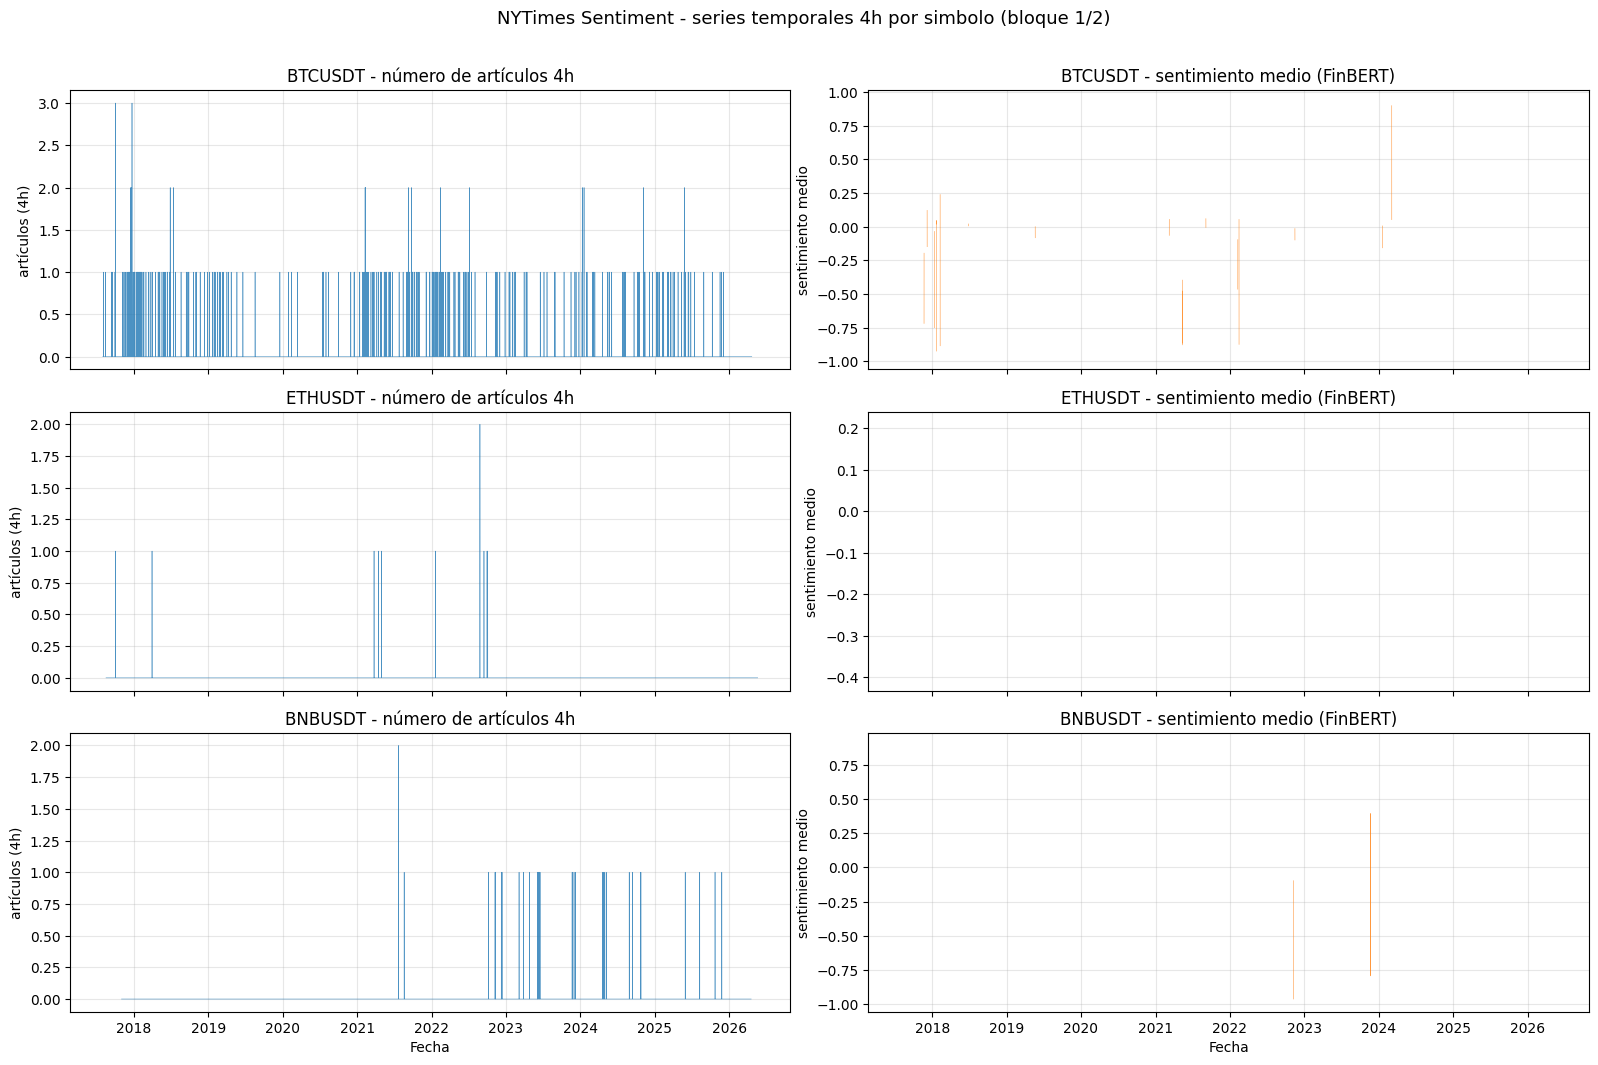

Figura guardada (bloque 1/2): /app/reports/validation/nytimes/figures/nytimes_series_4h_BLOCK1_20260603T233434Z.png


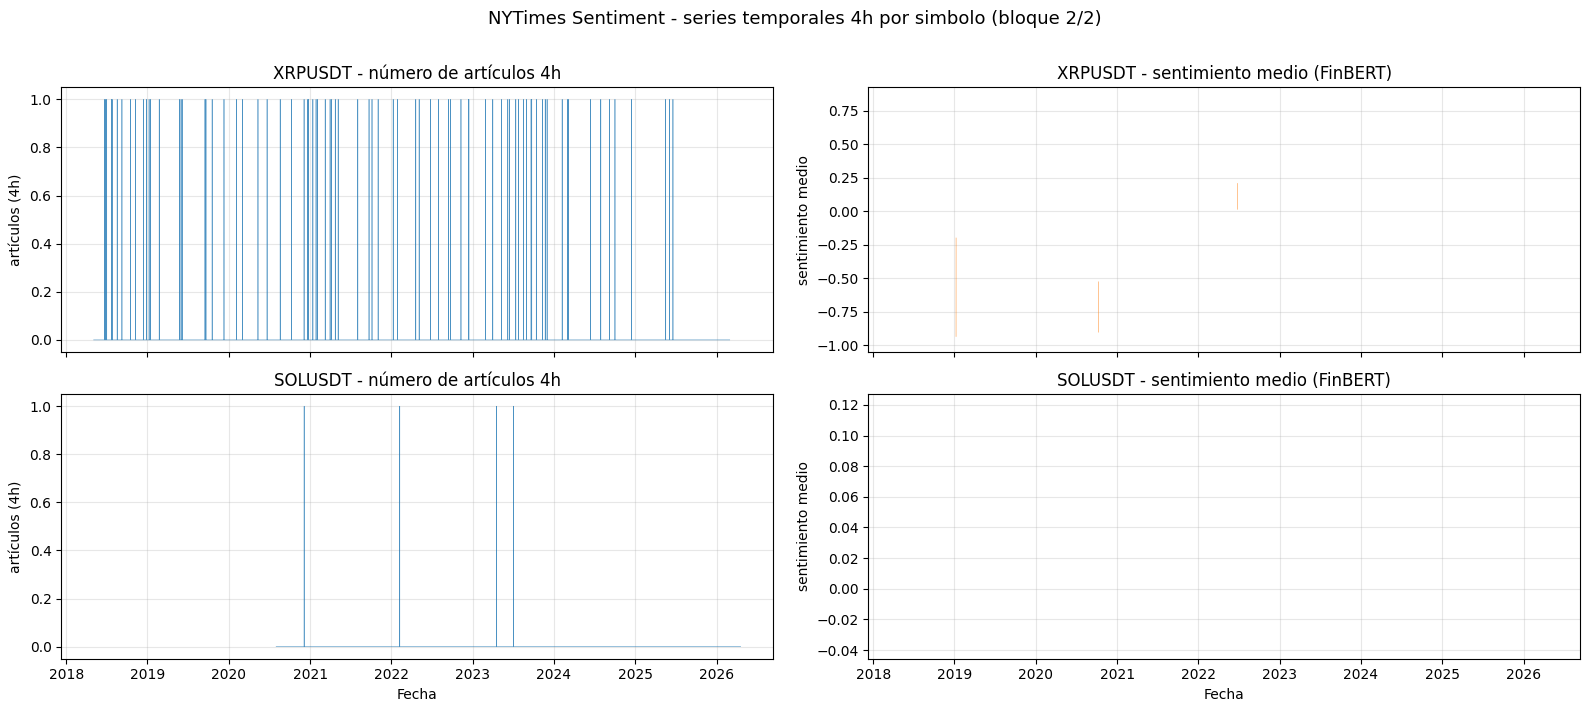

Figura guardada (bloque 2/2): /app/reports/validation/nytimes/figures/nytimes_series_4h_BLOCK2_20260603T233434Z.png


In [8]:
series_dict: dict[str, pd.DataFrame] = {}

if engine:
    for symbol in NYTIMES_SYMBOLS:
        q = text(
            f"""
            SELECT bucket_4h,
                   article_count,
                   sentiment_mean,
                   front_page_hits,
                   multimedia_count
            FROM {NYTIMES_FULL_TABLE}
            WHERE symbol = :symbol AND scope = 'symbol'
            ORDER BY bucket_4h
            """
        )
        df = pd.read_sql(q, engine, params={"symbol": symbol})
        if not df.empty:
            df["bucket_4h"] = pd.to_datetime(df["bucket_4h"])
            series_dict[symbol] = df

series_pares: list[tuple[str, pd.DataFrame]] = [
    (symbol, series_dict[symbol]) for symbol in NYTIMES_SYMBOLS if symbol in series_dict
]

pares_por_bloque = 3
fig_series_path_part1 = None
fig_series_path_part2 = None

if series_pares:
    bloques: list[list[tuple[str, pd.DataFrame]]] = [series_pares[:pares_por_bloque]]
    if len(series_pares) > pares_por_bloque:
        bloques.append(series_pares[pares_por_bloque:])

    for bloque_idx, bloque in enumerate(bloques, start=1):
        n_filas = len(bloque)
        fig, axes = plt.subplots(
            n_filas,
            2,
            figsize=(16, 3.5 * n_filas),
            sharex=True,
        )
        if n_filas == 1:
            axes = [axes]

        for fila_idx, (symbol, df) in enumerate(bloque):
            ax_count, ax_sent = axes[fila_idx]

            ax_count.plot(df["bucket_4h"], df["article_count"], linewidth=0.4, alpha=0.8)
            ax_count.set_ylabel("artículos (4h)")
            ax_count.set_title(f"{symbol} - número de artículos 4h")
            ax_count.xaxis.set_major_locator(mdates.YearLocator())
            ax_count.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax_count.grid(True, alpha=0.3)

            ax_sent.plot(
                df["bucket_4h"],
                df["sentiment_mean"],
                linewidth=0.4,
                alpha=0.8,
                color="tab:orange",
            )
            ax_sent.set_ylabel("sentimiento medio")
            ax_sent.set_title(f"{symbol} - sentimiento medio (FinBERT)")
            ax_sent.xaxis.set_major_locator(mdates.YearLocator())
            ax_sent.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax_sent.grid(True, alpha=0.3)

        axes[-1][0].set_xlabel("Fecha")
        axes[-1][1].set_xlabel("Fecha")
        n_bloques = len(bloques)
        fig.suptitle(
            f"NYTimes Sentiment - series temporales 4h por simbolo (bloque {bloque_idx}/{n_bloques})",
            fontsize=13,
            y=1.01,
        )
        plt.tight_layout()
        out_path = NYTIMES_FIGURES_DIR / f"nytimes_series_4h_BLOCK{bloque_idx}_{RUN_STAMP}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figura guardada (bloque {bloque_idx}/{n_bloques}): {out_path}")

        if bloque_idx == 1:
            fig_series_path_part1 = out_path
        else:
            fig_series_path_part2 = out_path
else:
    print("Sin datos para graficar series temporales.")


### 5.2. Muestra de filas recientes

La muestra final por entidad (cada símbolo y el agregado `MARKET`) permite comprobar la forma de los registros más recientes sin convertir el cuaderno en una exploración exhaustiva de la tabla completa. Se incluyen tanto los conteos brutos como los componentes del scoring FinBERT (positivo, negativo, neutro) y `coverage_ratio`.


In [9]:
muestras: dict[str, pd.DataFrame] = {}
COLUMNAS_MUESTRA_ES = {
    "scope": "ambito",
    "symbol": "simbolo",
    "bucket_4h": "bucket_4h_utc",
    "article_count": "num_articulos",
    "texts_analyzed": "textos_analizados",
    "sentiment_mean": "sentimiento_medio",
    "sentiment_positive": "sentimiento_positivo",
    "sentiment_negative": "sentimiento_negativo",
    "sentiment_neutral": "sentimiento_neutro",
    "front_page_hits": "portada",
    "multimedia_count": "multimedia",
    "coverage_ratio": "ratio_cobertura",
    "ingested_at": "ingesta_utc",
}

if engine:
    for symbol in NYTIMES_ENTITIES:
        scope = "market_wide" if symbol == NYTIMES_MARKET_SYMBOL else "symbol"
        q = text(
            f"""
            SELECT scope, symbol, bucket_4h,
                   article_count, texts_analyzed,
                   sentiment_mean, sentiment_positive,
                   sentiment_negative, sentiment_neutral,
                   front_page_hits, multimedia_count,
                   coverage_ratio,
                   ingested_at
            FROM {NYTIMES_FULL_TABLE}
            WHERE symbol = :symbol AND scope = :scope
            ORDER BY bucket_4h DESC
            LIMIT 5
            """
        )
        muestras[symbol] = pd.read_sql(
            q, engine, params={"symbol": symbol, "scope": scope}
        ).rename(columns=COLUMNAS_MUESTRA_ES)

for key, df in muestras.items():
    print(f"Muestra reciente: {key}")
    display(df)
    print("\n")


Muestra reciente: BTCUSDT


,ambito,simbolo,bucket_4h_utc,num_articulos,textos_analizados,sentimiento_medio,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,portada,multimedia,ratio_cobertura,ingesta_utc
0,symbol,BTCUSDT,2026-04-21 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:59:39.305320+00:00
1,symbol,BTCUSDT,2026-04-21 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:59:39.305317+00:00
2,symbol,BTCUSDT,2026-04-21 12:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:59:39.305314+00:00
3,symbol,BTCUSDT,2026-04-21 08:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:59:39.305311+00:00
4,symbol,BTCUSDT,2026-04-21 04:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:59:39.305308+00:00




Muestra reciente: ETHUSDT


,ambito,simbolo,bucket_4h_utc,num_articulos,textos_analizados,sentimiento_medio,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,portada,multimedia,ratio_cobertura,ingesta_utc
0,symbol,ETHUSDT,2026-05-20 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 22:26:08.241381+00:00
1,symbol,ETHUSDT,2026-05-19 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:56:17.318870+00:00
2,symbol,ETHUSDT,2026-05-19 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:56:17.318870+00:00
3,symbol,ETHUSDT,2026-05-19 12:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:56:17.318870+00:00
4,symbol,ETHUSDT,2026-05-19 08:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:56:17.318870+00:00




Muestra reciente: BNBUSDT


...

,ambito,simbolo,bucket_4h_utc,num_articulos,textos_analizados,sentimiento_medio,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,portada,multimedia,ratio_cobertura,ingesta_utc
0,symbol,XRPUSDT,2026-02-28 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-23 10:31:58.979122+00:00
1,symbol,XRPUSDT,2026-02-28 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-23 10:31:58.979122+00:00
2,symbol,XRPUSDT,2026-02-28 12:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-23 10:31:58.979122+00:00
3,symbol,XRPUSDT,2026-02-28 08:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-23 10:31:58.979122+00:00
4,symbol,XRPUSDT,2026-02-28 04:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-23 10:31:58.979122+00:00




Muestra reciente: SOLUSDT


,ambito,simbolo,bucket_4h_utc,num_articulos,textos_analizados,sentimiento_medio,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,portada,multimedia,ratio_cobertura,ingesta_utc
0,symbol,SOLUSDT,2026-04-18 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-19 22:48:32.472838+00:00
1,symbol,SOLUSDT,2026-04-18 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-19 22:48:32.472838+00:00
2,symbol,SOLUSDT,2026-04-18 12:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-19 22:48:32.472838+00:00
3,symbol,SOLUSDT,2026-04-18 08:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-19 22:48:32.472838+00:00
4,symbol,SOLUSDT,2026-04-18 04:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-19 22:48:32.472838+00:00




Muestra reciente: MARKET


,ambito,simbolo,bucket_4h_utc,num_articulos,textos_analizados,sentimiento_medio,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,portada,multimedia,ratio_cobertura,ingesta_utc
0,market_wide,MARKET,2026-05-20 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 22:25:56.830474+00:00
1,market_wide,MARKET,2026-05-19 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:40:17.267560+00:00
2,market_wide,MARKET,2026-05-19 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:40:17.267560+00:00
3,market_wide,MARKET,2026-05-19 12:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:40:17.267560+00:00
4,market_wide,MARKET,2026-05-19 08:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:40:17.267560+00:00


## 6. Auditoría de ingesta

La evidencia técnica no se limita a la tabla fact. A partir de `alternative_data.ingestion_runs` se construye un **resumen por modo de ejecución** (`historico` vs `live`) que cuantifica número de corridas, último arranque, filas totales y porcentaje de ejecuciones con fallo. Sobre ese mismo agregado se aísla un **diagnóstico específico de las corridas `live`**, útil para validar la operativa continua sin necesidad de inspeccionar registro a registro. Esta lectura permite distinguir si la tabla está sana porque el proceso terminó correctamente o si hay fallos recientes que conviene interpretar antes de usar la fuente en modelado.


In [10]:
_COLUMNAS_INGESTION_RUNS_ES = {
    "run_id": "id_ejecucion",
    "pipeline_type": "tipo_pipeline",
    "started_at": "inicio_utc",
    "finished_at": "fin_utc",
    "symbol_count": "cuenta_simbolos",
    "tasks_total": "tareas_totales",
    "success_count": "cuenta_exitos",
    "failed_count": "cuenta_fallos",
    "total_rows": "total_filas",
    "run_con_fallo": "ejecucion_con_fallo",
    "duracion_s": "duracion_seg",
}
advertencias_auditoria: list[str] = []
evidencia_runs_df = pd.DataFrame()

if engine:
    try:
        q_runs = text(
            """
            SELECT run_id,
                   pipeline_type,
                   started_at,
                   finished_at,
                   symbol_count,
                   tasks_total,
                   success_count,
                   failed_count,
                   total_rows
            FROM alternative_data.ingestion_runs
            WHERE pipeline_type IN (
                'etl_nytimes_sentiment',
                'etl_nytimes_sentiment_live',
                'etl_nytimes_sentiment_backfill',
                'etl_nytimes'
            )
            ORDER BY started_at DESC
            LIMIT 10;
            """
        )
        evidencia_runs_df = pd.read_sql(q_runs, engine)
    except Exception as exc:
        advertencias_auditoria.append(f"No se pudo consultar ingestion_runs: {exc}")

evidencia_auditoria_df_full = evidencia_runs_df.copy()
resumen_modos_df = pd.DataFrame()
diagnostico_live_df = pd.DataFrame()

if not evidencia_auditoria_df_full.empty:
    evidencia_auditoria_df_full["modo"] = evidencia_auditoria_df_full["pipeline_type"].map(
        lambda x: "live" if "live" in str(x).lower()
        else ("historico" if "backfill" in str(x).lower() else "historico")
    )
    evidencia_auditoria_df_full["run_con_fallo"] = (
        evidencia_auditoria_df_full["failed_count"].fillna(0).astype(int) > 0
    )

    resumen_modos_df = (
        evidencia_auditoria_df_full.groupby("modo", as_index=False)
        .agg(
            ejecuciones=("run_id", "count"),
            ultimo_inicio=("started_at", "max"),
            total_filas=("total_rows", "sum"),
            total_fallos_eventos=("failed_count", "sum"),
            ejecuciones_con_fallo=("run_con_fallo", "sum"),
        )
        .sort_values("modo")
    )
    resumen_modos_df["pct_ejecuciones_con_fallo"] = (
        (resumen_modos_df["ejecuciones_con_fallo"] / resumen_modos_df["ejecuciones"]) * 100.0
    ).round(2)

    _live_all = evidencia_auditoria_df_full[
        evidencia_auditoria_df_full["modo"] == "live"
    ].copy()
    if not _live_all.empty:
        _live_all["started_ts"] = pd.to_datetime(_live_all["started_at"], utc=True)
        _live_all["finished_ts"] = pd.to_datetime(_live_all["finished_at"], utc=True)
        _live_all["duracion_s"] = (
            _live_all["finished_ts"] - _live_all["started_ts"]
        ).dt.total_seconds().round(1)

        diagnostico_live_df = (
            _live_all[
                ["run_id", "pipeline_type", "started_at", "finished_at",
                 "success_count", "failed_count", "total_rows", "duracion_s", "run_con_fallo"]
            ]
            .sort_values("started_at", ascending=True)
            .rename(columns=_COLUMNAS_INGESTION_RUNS_ES)
        )

if advertencias_auditoria:
    display(pd.DataFrame({"advertencia": advertencias_auditoria}))

if not resumen_modos_df.empty:
    print("Resumen por modo de ejecución")
    display(resumen_modos_df)

if not diagnostico_live_df.empty:
    print("\nDiagnóstico de ejecuciones live")
    display(diagnostico_live_df)


Resumen por modo de ejecución


,modo,ejecuciones,ultimo_inicio,total_filas,total_fallos_eventos,ejecuciones_con_fallo,pct_ejecuciones_con_fallo
0,historico,5,2026-04-23 10:13:16.476753+00:00,56138,0,0,0.0
1,live,5,2026-05-20 22:29:02.319510+00:00,688,0,0,0.0



Diagnóstico de ejecuciones live


,id_ejecucion,tipo_pipeline,inicio_utc,fin_utc,cuenta_exitos,cuenta_fallos,total_filas,duracion_seg,ejecucion_con_fallo
7,b8690c62-4dd3-4007-ab9a-dd7d14de56e3,etl_nytimes_sentiment_live,2026-04-22 17:58:38.873381+00:00,2026-04-22 17:59:39.378946+00:00,2,0,36,60.5,False
3,acb6fca8-4d14-4bbe-9048-e1bd3d7860c5,etl_nytimes_sentiment_live,2026-05-20 21:34:50.723699+00:00,2026-05-20 21:56:43.038459+00:00,2,0,650,1312.3,False
2,ec21995b-aa03-4dde-89d3-f0cc4054aff2,etl_nytimes_sentiment_live,2026-05-20 21:57:35.986392+00:00,2026-05-20 21:57:38.455317+00:00,0,0,0,2.5,False
1,147f0fbd-2a74-4d4d-a825-924ae4048b10,etl_nytimes_sentiment_live,2026-05-20 22:25:55.784572+00:00,2026-05-20 22:26:08.679570+00:00,0,0,2,12.9,False
0,3939b26f-f206-45ea-adff-44bcd583d51e,etl_nytimes_sentiment_live,2026-05-20 22:29:02.319510+00:00,2026-05-20 22:29:04.791048+00:00,0,0,0,2.5,False


## 7. Inventario de artefactos Parquet en disco

El inventario contrasta los ficheros raw esperados (uno por entidad: `market_wide`/`MARKET` y cada símbolo) con los artefactos disponibles bajo el directorio snapshot configurado para NYTimes. Esta evidencia permite reconstruir la tabla sin depender de una nueva llamada a la fuente externa y deja un respaldo en disco frente a la tabla materializada.


In [11]:
settings_inv = Settings.load_from_yaml(ROOT / "config" / "settings.yaml")
_nt = settings_inv.alternative_data.nytimes_sentiment
NYTIMES_RAW_DIR = Path(
    _nt.parquet.snapshot_dir
    if _nt is not None
    else (ROOT / "data" / "01_raw" / "nytimes")
).resolve()

parquet_rows: list[dict] = []
_entities_inv = [("market_wide", NYTIMES_MARKET_SYMBOL)] + [
    ("symbol", s) for s in NYTIMES_SYMBOLS
]

for _scope, _sym in _entities_inv:
    archivo = f"nytimes_sentiment_{_scope}_{_sym}.parquet".replace("/", "_")
    raw_path = NYTIMES_RAW_DIR / archivo

    if not raw_path.exists():
        parquet_rows.append({
            "tipo": "raw_nytimes_snapshot",
            "ambito": _scope,
            "simbolo": _sym,
            "archivo": archivo,
            "tamano_mb": None,
            "filas": None,
            "columnas": None,
            "min_timestamp": None,
            "max_timestamp": None,
        })
        continue

    tamano_mb = raw_path.stat().st_size / (1024 * 1024)
    try:
        raw_df = pd.read_parquet(raw_path)
        timestamps = (
            pd.to_datetime(raw_df["bucket_4h"], utc=True, errors="coerce").dropna()
            if "bucket_4h" in raw_df.columns
            else pd.Series(dtype="datetime64[ns, UTC]")
        )
        parquet_rows.append({
            "tipo": "raw_nytimes_snapshot",
            "ambito": _scope,
            "simbolo": _sym,
            "archivo": archivo,
            "tamano_mb": round(tamano_mb, 2),
            "filas": len(raw_df),
            "columnas": len(raw_df.columns),
            "min_timestamp": timestamps.min() if not timestamps.empty else None,
            "max_timestamp": timestamps.max() if not timestamps.empty else None,
        })
    except Exception:
        parquet_rows.append({
            "tipo": "raw_nytimes_snapshot",
            "ambito": _scope,
            "simbolo": _sym,
            "archivo": archivo,
            "tamano_mb": round(tamano_mb, 2),
            "filas": None,
            "columnas": None,
            "min_timestamp": None,
            "max_timestamp": None,
        })

parquet_inventory_df = pd.DataFrame(parquet_rows)
display(parquet_inventory_df)


,tipo,ambito,simbolo,archivo,tamano_mb,filas,columnas,min_timestamp,max_timestamp
0,raw_nytimes_snapshot,market_wide,MARKET,nytimes_sentiment_market_wide_MARKET.parquet,0.26,19285,22,2017-08-01 00:00:00+00:00,2026-05-20 20:00:00+00:00
1,raw_nytimes_snapshot,symbol,BTCUSDT,nytimes_sentiment_symbol_BTCUSDT.parquet,0.23,19116,22,2017-08-01 00:00:00+00:00,2026-04-21 20:00:00+00:00
2,raw_nytimes_snapshot,symbol,ETHUSDT,nytimes_sentiment_symbol_ETHUSDT.parquet,0.22,19189,22,2017-08-17 00:00:00+00:00,2026-05-20 20:00:00+00:00
3,raw_nytimes_snapshot,symbol,BNBUSDT,nytimes_sentiment_symbol_BNBUSDT.parquet,0.21,18546,22,2017-11-01 00:00:00+00:00,2026-04-18 20:00:00+00:00
4,raw_nytimes_snapshot,symbol,XRPUSDT,nytimes_sentiment_symbol_XRPUSDT.parquet,0.20,17148,22,2018-05-04 00:00:00+00:00,2026-02-28 20:00:00+00:00
5,raw_nytimes_snapshot,symbol,SOLUSDT,nytimes_sentiment_symbol_SOLUSDT.parquet,0.15,12522,22,2020-08-01 00:00:00+00:00,2026-04-18 20:00:00+00:00


## 8. Exportación de artefactos para reproducibilidad

Las tablas vistas son útiles dentro del cuaderno, pero la memoria del TFG y la auditoría externa necesitan **artefactos persistentes** en disco. En esta celda se vuelca todo lo anterior bajo `reports/validation/nytimes/`, con un sello UTC (`<stamp>`) en el nombre para no sobrescribir corridas previas (p. ej. `20260603T233434Z` en esta corrida).

- **JSON consolidado:** `nytimes_validation_<stamp>.json` (metadatos, fecha de corte, entidades, resultado global, fallos accionables, matriz de comprobaciones, cobertura, duplicados PK, integridad de sentimiento, consistencia, auditoría, inventario *Parquet* y rutas de figuras).

- **Nueve CSV** (mismo `<stamp>`): `nytimes_validation_summary_`, `cobertura_`, `resumen_simbolos_`, `duplicados_`, `integridad_`, `consistencia_`, `modos_`, `diagnostico_live_`, `parquet_inventory_`.

- **Dos PNG** en `reports/validation/nytimes/figures/`: `nytimes_series_4h_BLOCK1_<stamp>.png` y `nytimes_series_4h_BLOCK2_<stamp>.png` (series 4h de la sección 5).

Al final se imprime el **resultado global** (`PASS`/`FAIL`) y comprobaciones breves de **duplicados**, **integridad de sentimiento**, **completitud de modos** e **inventario Parquet** *raw*, seguidas de las rutas del JSON, de los CSV y de las figuras. Por último se libera la conexión con `engine.dispose()` si el kernel sigue vivo.


In [12]:
export_paths = {
    "json": NYTIMES_OUTPUT_DIR / f"nytimes_validation_{RUN_STAMP}.json",
    "summary": NYTIMES_OUTPUT_DIR / f"nytimes_validation_summary_{RUN_STAMP}.csv",
    "cobertura": NYTIMES_OUTPUT_DIR / f"nytimes_validation_cobertura_{RUN_STAMP}.csv",
    "resumen_simbolos": NYTIMES_OUTPUT_DIR / f"nytimes_validation_resumen_simbolos_{RUN_STAMP}.csv",
    "duplicados": NYTIMES_OUTPUT_DIR / f"nytimes_validation_duplicados_{RUN_STAMP}.csv",
    "integridad": NYTIMES_OUTPUT_DIR / f"nytimes_validation_integridad_{RUN_STAMP}.csv",
    "consistencia": NYTIMES_OUTPUT_DIR / f"nytimes_validation_consistencia_{RUN_STAMP}.csv",
    "modos": NYTIMES_OUTPUT_DIR / f"nytimes_validation_modos_{RUN_STAMP}.csv",
    "diagnostico_live": NYTIMES_OUTPUT_DIR / f"nytimes_validation_diagnostico_live_{RUN_STAMP}.csv",
    "parquet_inventory": NYTIMES_OUTPUT_DIR / f"nytimes_validation_parquet_inventory_{RUN_STAMP}.csv",
}

duplicados_ok = bool(not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all())
integridad_ok = bool(not integridad_df.empty and len(integridad_df) >= len(NYTIMES_ENTITIES))
historico_ok = bool(not resumen_modos_df.empty and (resumen_modos_df["modo"] == "historico").any())
live_ok = bool(not resumen_modos_df.empty and (resumen_modos_df["modo"] == "live").any())
parquet_ok = bool(
    not parquet_inventory_df.empty
    and parquet_inventory_df["tamano_mb"].notna().sum() == len(parquet_inventory_df)
)

payload = {
    "metadata": run_meta,
    "fecha_corte": FECHA_CORTE,
    "entidades": NYTIMES_ENTITIES,
    "resultado_global": "PASS" if accepted else "FAIL",
    "fallos_accionables": actionable_failures,
    "checks": summary_df.to_dict(orient="records"),
    "cobertura": {
        "detalle_por_entidad": evidencia_cobertura_df.to_dict(orient="records") if not evidencia_cobertura_df.empty else [],
    },
    "duplicados_pk": {
        "verificado": duplicados_ok,
        "cero_duplicados_todas_entidades": duplicados_ok,
        "detalle": duplicados_pk_df.to_dict(orient="records") if not duplicados_pk_df.empty else [],
    },
    "integridad_sentimiento": {
        "verificado": integridad_ok,
        "detalle": integridad_df.to_dict(orient="records") if not integridad_df.empty else [],
    },
    "consistencia": consistencia_df.to_dict(orient="records") if not consistencia_df.empty else [],
    "completitud_etl": {
        "historico_detectado": historico_ok,
        "live_detectado": live_ok,
    },
    "auditoria": {
        "resumen_modos": resumen_modos_df.to_dict(orient="records") if not resumen_modos_df.empty else [],
        "diagnostico_live": diagnostico_live_df.to_dict(orient="records") if not diagnostico_live_df.empty else [],
        "advertencias": advertencias_auditoria,
    },
    "inventario_parquet": {
        "archivos_encontrados": int(parquet_inventory_df["tamano_mb"].notna().sum()) if not parquet_inventory_df.empty else 0,
        "archivos_esperados": len(parquet_inventory_df) if not parquet_inventory_df.empty else 0,
        "detalle": parquet_inventory_df.to_dict(orient="records") if not parquet_inventory_df.empty else [],
    },
    "figuras": {
        "series_4h_png_bloque_1": str(fig_series_path_part1) if fig_series_path_part1 else None,
        "series_4h_png_bloque_2": str(fig_series_path_part2) if fig_series_path_part2 else None,
    },
}

export_paths["json"].write_text(json.dumps(payload, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
summary_df.to_csv(export_paths["summary"], index=False)
if not evidencia_cobertura_df.empty:
    evidencia_cobertura_df.to_csv(export_paths["cobertura"], index=False)
if not resumen_simbolos_df.empty:
    resumen_simbolos_df.to_csv(export_paths["resumen_simbolos"], index=False)
if not duplicados_pk_df.empty:
    duplicados_pk_df.to_csv(export_paths["duplicados"], index=False)
if not integridad_df.empty:
    integridad_df.to_csv(export_paths["integridad"], index=False)
if not consistencia_df.empty:
    consistencia_df.to_csv(export_paths["consistencia"], index=False)
if not resumen_modos_df.empty:
    resumen_modos_df.to_csv(export_paths["modos"], index=False)
if not diagnostico_live_df.empty:
    diagnostico_live_df.to_csv(export_paths["diagnostico_live"], index=False)
if not parquet_inventory_df.empty:
    parquet_inventory_df.to_csv(export_paths["parquet_inventory"], index=False)

print(f"Resultado global: {'PASS' if accepted else 'FAIL'}")
print(f"Duplicados = 0 verificado: {'OK' if duplicados_ok else 'PENDIENTE'}")
print(f"Integridad de sentimiento por entidad: {'OK' if integridad_ok else 'PENDIENTE'}")
print(f"Historico detectado: {'OK' if historico_ok else 'PENDIENTE'}")
print(f"Live detectado: {'OK' if live_ok else 'PENDIENTE'}")
print(f"Inventario Parquet completo: {'OK' if parquet_ok else 'PENDIENTE'}")
print(f"Evidencia JSON: {export_paths['json']}")
for _name, _p in export_paths.items():
    if _name == "json":
        continue
    if _p.exists():
        print(f"CSV {_name}: {_p}")
if fig_series_path_part1:
    print(f"Figura series 4h (bloque 1): {fig_series_path_part1}")
if fig_series_path_part2:
    print(f"Figura series 4h (bloque 2): {fig_series_path_part2}")

if engine is not None:
    engine.dispose()


Resultado global: FAIL
Duplicados = 0 verificado: OK
Integridad de sentimiento por entidad: OK
Historico detectado: OK
Live detectado: OK
Inventario Parquet completo: OK
Evidencia JSON: /app/reports/validation/nytimes/nytimes_validation_20260603T233434Z.json
CSV summary: /app/reports/validation/nytimes/nytimes_validation_summary_20260603T233434Z.csv
CSV cobertura: /app/reports/validation/nytimes/nytimes_validation_cobertura_20260603T233434Z.csv
CSV resumen_simbolos: /app/reports/validation/nytimes/nytimes_validation_resumen_simbolos_20260603T233434Z.csv
CSV duplicados: /app/reports/validation/nytimes/nytimes_validation_duplicados_20260603T233434Z.csv
CSV integridad: /app/reports/validation/nytimes/nytimes_validation_integridad_20260603T233434Z.csv
CSV consistencia: /app/reports/validation/nytimes/nytimes_validation_consistencia_20260603T233434Z.csv
CSV modos: /app/reports/validation/nytimes/nytimes_validation_modos_20260603T233434Z.csv
CSV diagnostico_live: /app/reports/validation/nyti

## 9. Conclusiones

Para el universo `{BTCUSDT, ETHUSDT, BNBUSDT, XRPUSDT, SOLUSDT}` más el agregado `MARKET` (scope `market_wide`), con **fecha de corte** fijada por el validador, esta ejecución (`stamp` `20260603T233434Z`, `fecha_hora_utc` **2026-06-03 23:34 UTC**) deja una lectura en cuatro capas:

1. **Ingesta estructural**: el validador cierra con resultado global `FAIL` porque `SENTIMENT_COVERAGE` es la única comprobación requerida en fallo; el resto de checks requeridos figuran en `PASS`. Las evidencias SQL muestran **105,806** filas en la vista agregada (seis entidades), **0** duplicados por PK e integridad por entidad en OK. La auditoría registra **10** ejecuciones (**5** histórico, **5** *live*): **56,138** / **688** filas reportadas por modo, sin fallos de evento en esta corrida.

2. **Cobertura de señal (*FinBERT*)**: la ausencia de `sentiment_mean` se interpreta como *falta de score disponible* en un bucket con actividad, no como un hueco de mercado equivalente a una vela faltante en precio. En esta corrida, `pct_sentimiento_real` alcanza **4.09 %** en `MARKET`, **1.78 %** en `BTCUSDT`, **0.48 %** en `XRPUSDT`, **0.22 %** en `BNBUSDT`, **0.05 %** en `ETHUSDT` y **0.03 %** en `SOLUSDT`; el `FAIL` de `SENTIMENT_COVERAGE` documenta que el ratio mínimo configurado no se cumple para todos los símbolos.

3. **Reproducibilidad**: el inventario de *Parquet* en disco (snapshot canónico por `scope`/`symbol`) asegura trazabilidad; los **nueve CSV**, el **JSON** y los **dos PNG** bajo `reports/validation/nytimes/` son los artefactos citables en memoria.

4. **Limitación interpretativa**: NYTimes aporta una señal auxiliar de atención mediática generalista y tono, irregular por naturaleza y concentrada en episodios de mayor relevancia pública. Complementa las capas de mercado (OHLCV y resto del backbone), pero no sustituye precio, volumen ni otras señales observacionales directas.

**Nota.** Resultado global, estados de `summary_df` y rutas con `stamp` dependen del estado del proyecto al ejecutar el cuaderno; en otra corrida pueden cambiar.
